# 평면 사진을 가상 카메라로 촬영하기

실제 사진을 **평평한 포스터의 표면**으로 놓고 가상 카메라에서 어떻게 보이는지 계산합니다. 같은 평면을 3D 카메라 행렬과 2D Homography로 투영한 결과가 일치하는지 확인한 다음 사진을 정면으로 펴 봅니다. 두 장의 실제 카메라 사진에서 특징점을 찾거나 3D 구조를 추정하는 과제는 아닙니다.

CPU/Colab에서 실행합니다. NumPy, Matplotlib, OpenCV, scikit-image가 필요합니다. Colab에 없다면 별도 셀에서 `%pip install -q opencv-python-headless scikit-image matplotlib`을 한 번 실행하세요. 사진은 `skimage.data.astronaut()` 예제입니다.


In [3]:
#dependency 설치 안됐으면 실행. 설치 됐으면 다음 셀부터 실행
%pip install -q opencv-python-headless scikit-image matplotlib 
#--user   permission error뜨면 --user 추가

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from skimage import data

np.set_printoptions(precision=3, suppress=True)
print('Libraries ready')


Libraries ready


## 1. 사진을 $Z=0$ 평면에 놓기

사진의 픽셀 $(u,v)$를 실제 포스터 표면 좌표 $(X,Y,0)$에 대응시킵니다. 계산이 간단하도록 포스터 가로·세로 길이를 모두 **2 임의 단위**로 정의합니다. $X,Y\in[-1,1]$이며 이미지에서 아래로 갈수록 $Y$가 증가합니다. 이는 이번 실험의 좌표계 선택입니다.


Image corners mapped to plane: [[-1. -1.  0.]
 [ 1. -1.  0.]
 [ 1.  1.  0.]
 [-1.  1.  0.]]


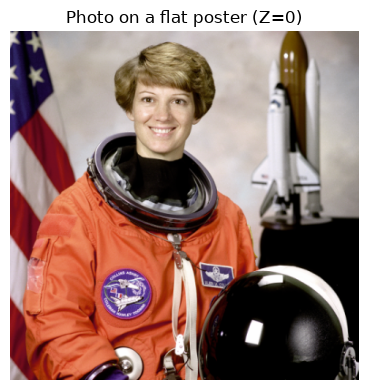

In [13]:
photo = cv2.resize(data.astronaut(), (384, 384), interpolation=cv2.INTER_AREA)
height, width = photo.shape[:2]     # 이미지 배열에서 높이와 너비를 가져옴
W_canvas, H_canvas = 640, 480   # 나중에 사용할 출력 화면 크기를 640*480으로 정함

# [u, v, 1]^T -> [X, Y, 1]^T (포스터의 Z=0 평면)
# 픽셀 좌표를 평면 좌표로 바꾸는 행렬
S = np.array([[2/(width-1), 0, -1],
              [0, 2/(height-1), -1],
              [0, 0, 1.]], dtype=float)
# 사진의 네 모서리 좌표 만들기
corners_uv = np.array([[0, 0], [width-1, 0],
                       [width-1, height-1], [0, height-1]], dtype=float)
# (u, v, 1) 형태의 동차 좌표
corners_h = np.column_stack([corners_uv, np.ones(4)])
# 각 점을 열벡터로 배치하고 변환 행렬을 적용
# 한 행에 오도록 바꾸고 모든 행에서 앞의 두 열만 가져오기
corners_xy = (S @ corners_h.T).T[:, :2]
corners_xyz = np.column_stack([corners_xy, np.zeros(4)]) # 각 점에 Z좌표 0을 붙임
print('Image corners mapped to plane:', corners_xyz)

plt.figure(figsize=(4,4));plt.imshow(photo);plt.title('Photo on a flat poster (Z=0)')
plt.axis('off');plt.tight_layout();plt.show()


## 2. 가상 카메라 $P=K[R|t]$

카메라 내부행렬 $K$는 초점거리와 주점 $(c_x,c_y)$을 픽셀 단위로 지정합니다. $R,t$는 **세계좌표에서 카메라 좌표로** 바꾸는 변환이므로 $X_c=RX_w+t$입니다. 여기의 $t$는 카메라 중심 $C$ 자체가 아닙니다. 포스터 앞에 카메라를 두고 기울여 봅니다.


In [14]:
def rot_x(degrees):
    a = np.deg2rad(degrees)     # 입력한 각도를 라디안으로 변환
    # x축을 기준으로 회전하는 행렬
    return np.array([[1, 0, 0], [0, np.cos(a), -np.sin(a)],
                     [0, np.sin(a), np.cos(a)]], dtype=float)

def rot_y(degrees):
    a = np.deg2rad(degrees)
    # y축을 기준으로 회전하는 행렬
    return np.array([[np.cos(a), 0, np.sin(a)], [0, 1, 0],
                     [-np.sin(a), 0, np.cos(a)]], dtype=float)

# x축 회전 18도 -> y축 회전 25도
R = rot_y(25) @ rot_x(18)   # 순서를 바꾸면 결과가 달라집니다.
# 카메라 좌표 변환에서 더할 이동 벡터
# 세계 좌표 원점은 카메라 좌표 (0.1, 0, 3.2)가 됨
t = np.array([0.1, 0.0, 3.2])
# 카메라 내부 설정 (Intrinsic Parameters)
# f: x, y 방향에 동일하게 사용하는 초점거리
# cx, cy: 주점(이 코드에서는 화면 중앙으로 설정)
f, cx, cy = 560., 320., 240.
# 카메라 내부 행렬 (Intrinsic matrix K)
K = np.array([[f, 0., cx], [0., f, cy], [0., 0., 1.]])
# R이 올바른 회전 행렬인지 확인
# 회전 행렬은 det(R) = 1, R의 전치행렬과 R의 곱이 단위행렬이어야 함
print('det(R) =', round(np.linalg.det(R), 6))
print('R^T R =', R.T @ R)


det(R) = 1.0
R^T R = [[ 1.  0. -0.]
 [ 0.  1. -0.]
 [-0. -0.  1.]]


In [15]:
def project(K, R, t, X_world):
    """TODO 1: X_camera=R X_world+t, x_h=K X_camera, 마지막 성분으로 나누기."""
    # X_world.shape = (N,3), 반환 shape = (N,2)
    
    # 세계 좌표 -> 카메라 좌표
    # World Coordinate : 실제 3D 공간에 있는 점
    # Camera Coordinate : 그 점을 카메라를 원점으로 하는 3D 좌표계에서 표현한 점
    X_camera = X_world @ R.T + t

    # 카메라 내부 행렬을 곱해 3D 카메라 좌표를 2D 픽셀 좌표로 변환
    # Pixel Coordinate : 최종 사진의 어느 위치에 물체가 나타나는지 표현하는 2D 좌표
    x_h = X_camera @ K.T

    # 앞의 두 성분을 마지막 성분으로 나눠 픽셀 좌표 계산
    x = x_h[:, :2] / x_h[:, 2:3]

    return x


Four corner pixels: [[163.034  80.663]
 [516.37   26.734]
 [528.235 414.195]
 [223.041 376.468]]


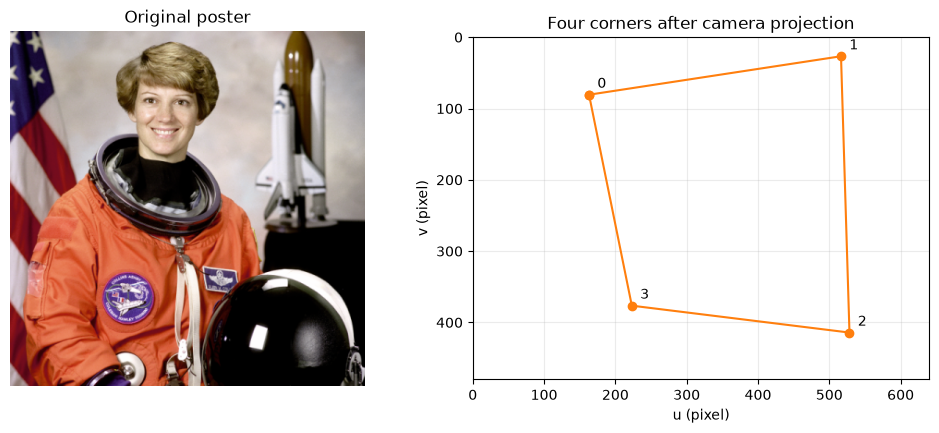

In [16]:
projected_corners = project(K, R, t, corners_xyz)
print('Four corner pixels:', projected_corners)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
axes[0].imshow(photo)
axes[0].set_title('Original poster')
axes[0].axis('off')
quad = np.vstack([projected_corners, projected_corners[0]])
axes[1].plot(quad[:,0], quad[:,1], 'o-', color='tab:orange')
for idx, point in enumerate(projected_corners):
    axes[1].annotate(str(idx),point,xytext=(6,5),textcoords='offset points')
axes[1].set(xlim=(0,W_canvas),ylim=(H_canvas,0),
            title='Four corners after camera projection',xlabel='u (pixel)',ylabel='v (pixel)')
axes[1].set_aspect('equal')
axes[1].grid(alpha=.25)
plt.tight_layout();plt.show()


## 3. 왜 평면에는 하나의 Homography가 적용될까?

포스터의 모든 점은 $Z=0$이므로

$$\tilde{x} \sim K[R|t](X,Y,0,1)^T
=K[r_1\;r_2\;t](X,Y,1)^T.$$

앞의 픽셀→평면 행렬 $S$를 곱하면 원본 사진 픽셀을 가상 카메라 픽셀로 보내는 $H=K[r_1\;r_2\;t]S$가 됩니다. 동차좌표는 **마지막 성분으로 나눈 뒤** 비교해야 합니다.

Homography : 하나의 평면에 있는 점들을 다른 이미지 평면의 점들로 대응시키는 2D Projective Transformation


In [17]:
def plane_homography(K, R, t, S):
    """TODO 2: H = K [r1 r2 t] S를 구현하세요."""

    # R의 첫 번째 열과 두 번째 열
    r1 = R[:, 0]
    r2 = R[:, 1]

    # 세 열 r1, r2, t를 옆에 붙여 3*3 행렬 생성
    # Z=0 평면의 좌표 [X, Y, 1]을 카메라 좌표로 변환
    Rt_plane = np.array([
        [r1[0], r2[0], t[0]],
        [r1[1], r2[1], t[1]],
        [r1[2], r2[2], t[2]]
    ])

    # S : 원본 사진의 픽셀 -> 평면 좌표
    # Rt_plane : 평면 좌표 -> 카메라 좌표
    # K : 카메라 좌표 -> homogeneous 이미지 좌표
    H = K @ Rt_plane @ S

    return H

H = plane_homography(K, R, t, S)
print('det(H) =', round(np.linalg.det(H), 6))


det(H) = 23.930592


In [18]:
def transform_points(H, uv):
    # 각 픽셀 좌표 [u, v] 뒤에 1을 붙임
    uv_h = np.column_stack([uv, np.ones(len(uv))])
    # H를 적용해 각 점의 homogeneous 이미지 좌표 계산
    warped_h = (H @ uv_h.T).T
    # [a, b, c] -> [a/c, b/c]
    return warped_h[:, :2] / warped_h[:, 2, None]

by_H = transform_points(H, corners_uv)
difference = np.max(np.abs(by_H - projected_corners))
print('Max |homography pixel - 3D projection pixel|:',difference)
assert difference < 1e-9

# 직선 위 세 점의 변환 후 공선성 확인 (행렬식이 0에 가까움)
line_uv = np.array([[30., 90.], [185., 90.], [340., 90.]])
line_warped = transform_points(H, line_uv)
collinearity_det = np.linalg.det(np.column_stack([line_warped,np.ones(3)]))
print('Collinearity determinant:',collinearity_det)


Max |homography pixel - 3D projection pixel|: 1.4210854715202004e-14
Collinearity determinant: 1.0391315735797691e-11


## 4. 사진을 기울이고 다시 정면으로 펴기

`warpPerspective()`로 포스터가 가상 카메라에 보이는 영상을 만듭니다. 같은 $H$의 역행렬로 정면 영상을 복원해 봅니다. 영상은 보간을 두 번 거치므로 픽셀값이 완전히 같아지지는 않습니다.


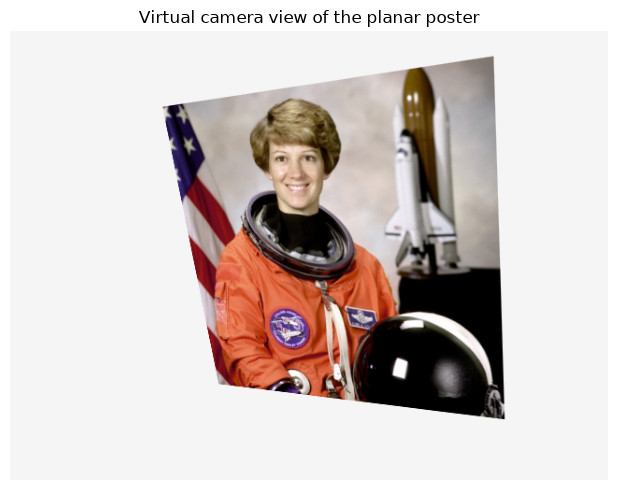

In [19]:
oblique = cv2.warpPerspective(photo, H, (W_canvas,H_canvas),
                              flags=cv2.INTER_LINEAR,
                              borderValue=(245,245,245))
plt.figure(figsize=(8,5));plt.imshow(oblique)
plt.title('Virtual camera view of the planar poster')
plt.axis('off');plt.tight_layout();plt.show()


In [20]:
# TODO 3: 위의 기울어진 이미지를 H의 역행렬로 정면 복원하세요.

# H의 역행렬 (기울어진 화면 좌표를 원본 사진 좌표로 되돌림)
H_inv = np.linalg.inv(H)

# 기울어진 사진을 원본 크기로 복원
rectified = cv2.warpPerspective(
    oblique,            # 복원 대상인 기울어진 사진
    H_inv,              # 되돌리는 변환 행렬
    (width, height)     # 결과 이미지의 크기
)


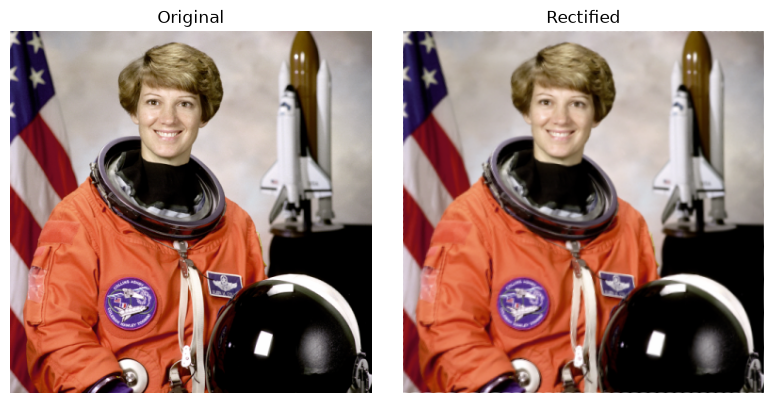

Central region mean absolute pixel error: 2.7 / 255


In [21]:
fig, axes = plt.subplots(1,2,figsize=(8,4))
axes[0].imshow(photo);axes[0].set_title('Original')
axes[1].imshow(rectified);axes[1].set_title('Rectified')
for ax in axes: ax.axis('off')
plt.tight_layout();plt.show()
margin=25
crop=(slice(margin,-margin),slice(margin,-margin))
mae=np.mean(np.abs(photo[crop].astype(float)-rectified[crop].astype(float)))
print('Central region mean absolute pixel error:',round(mae,2),'/ 255')


## 5. 초점거리와 거리 바꾸기

코드에 같은 3D 포스터를 유지하면서 $f$와 카메라의 $t_z$만 바꿔 네 장의 그림을 그립니다. 각 조건에서 $H$를 다시 계산합니다. 중심 이동과 크기 변화에 주목하세요.


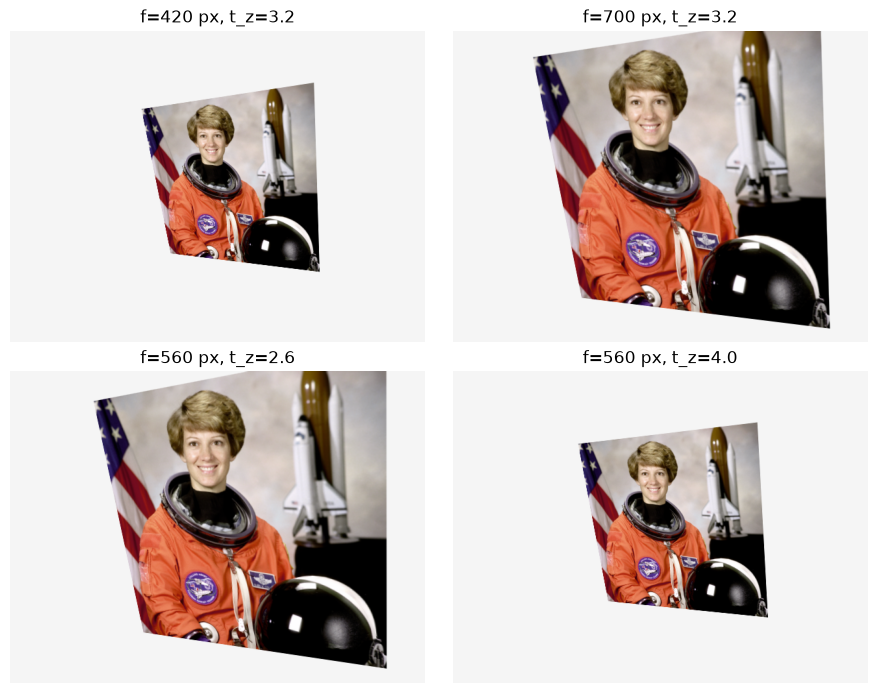

In [22]:
experiments = [(420.,3.2),(700.,3.2),(560.,2.6),(560.,4.0)]
fig,axes=plt.subplots(2,2,figsize=(9,7))
for ax,(f_try,tz_try) in zip(axes.ravel(),experiments):
    K_try = np.array([[f_try,0.,cx],[0.,f_try,cy],[0.,0.,1.]])
    t_try = np.array([t[0],t[1],tz_try])
    H_try = plane_homography(K_try,R,t_try,S)
    shown = cv2.warpPerspective(photo,H_try,(W_canvas,H_canvas),
                                borderValue=(245,245,245))
    ax.imshow(shown)
    ax.set_title(f'f={f_try:.0f} px, t_z={tz_try:.1f}')
    ax.axis('off')
plt.tight_layout();plt.show()


## Discussion

1. $Z=0$인 평면의 네 꼭짓점에서 `project()`와 `plane_homography()`가 같은 결과를 주는 이유를 한 식으로 설명하세요. 출력된 두 좌표의 최대 차이도 적으세요.


답변 : 포스터의 모든 점은 Z = 0이므로 다음의 식이 성립된다.
$$
\begin{aligned}
\tilde{x} &\sim K[R|t](X,Y,0,1)^T\\
&=K[r_1\;r_2\;t]S(u,v,1)^T\\
&=H(u,v,1)^T
\end{aligned}
$$
따라서 project()로 3차원 점을 투영하는 것과 plane_homography()로 만든 H를 적용하는 것은 같은 계산이다. 두 결과를 각각 마지막 성분으로 나누면 동일한 픽셀 좌표를 가진다. 출력된 두 좌표의 최대 차이는 약 1.42*(10^(-14)) 픽셀로, 부동소수점 계산 오차 수준이다.

2. 초점거리 $f$를 늘릴 때와 거리 $t_z$를 늘릴 때 포스터 크기는 각각 어떻게 달라지나요? 마지막의 네 장 그림을 근거로 설명하세요.



답변 : 거리를 일정하게 두고 초점거리 f를 증가시키면 포스터가 크게 보인다. 위의 두 그림에서 t_z는 3.2로 같지만, f = 700일 때가 f = 420일 때보다 포스터가 크게 나타난다. 반대로 초점거리를 일정하게 두고 t_z를 늘리면 포스터가 작게 보인다. 위의 두 그림에서 f는 560 px로 같지만 t_z = 4.0일 때가 t_z = 2.6일 때보다 포스터가 작게 나타난다.
이는 원근 투영 식 (u=fX_c/Z_c+c_x), (v=fY_c/Z_c+c_y)로 설명할 수 있다. 초점거리 f가 커지면 주점으로부터 투영된 점까지의 거리가 증가하고, 깊이 Z_c가 커지면 그 거리가 감소하기 때문이다. 따라서 초점거리와 깊이는 모두 이미지 크기에 영향을 주지만 서로 반대 방향으로 작용한다.

3. 포스터 앞에 3D 물체를 하나 놓아 $Z$가 서로 다른 점들을 포함시키면 **동일한 평면 Homography 하나**로 모든 점을 옮길 수 있을까요? 강의 4의 parallax 설명(18쪽)과 연결하세요.


답변 : 일반적으로 하나의 평면 Homography로 서로 다른 깊이에 존재하는 3D 물체의 모든 점을 정확하게 변환할 수 없다. 그 이유는 Homography는 동일한 평면 위에 있는 점들 사이의 투영 관계를 나타내기 때문이다.

포스터 앞에 3D 물체를 놓으면 포스터와 물체의 각 점은 서로 다른 깊이를 가지게 된다. 이때 카메라의 위치가 변하면 깊이에 따라 영상에서 물체가 이동하는 정도가 달라지는 parallax가 발생한다. 강의 자료의 예시처럼 가까운 물체는 크게 이동하고 먼 물체는 상대적으로 적게 이동한다. 따라서 서로 다른 깊이에 존재하는 점들은 동일한 변환 관계를 따르지 않으므로, 하나의 Homography로 전체 장면을 정확하게 변환하기 어렵다.